## PLN 2026 - Trabalho da disciplina
Baseado no exemplo de Classificação de textos com TF-IDF (Prof. Maiko Spiess)

---

## Classificação de notícias do Lance!

Este notebook aplica à base de notícias do nosso projeto ([github.com/pkalbuquerque/pln](https://github.com/pkalbuquerque/pln)) o pipeline da aula de classificação, que usou o corpus B2W-Reviews01:

**texto → representação TF-IDF → classificador → classe prevista → avaliação**

Mantemos os dois problemas da aula, adaptados à nossa base:

1. **Classificação binária**: a notícia é do **Flamengo** ou não?
2. **Classificação multiclasse**: de qual **seção** (clube ou editoria) é a notícia?

A base tem poucas dezenas de notícias, bem menos que as 30 mil avaliações da aula. Por isso, além da divisão treino/teste, usamos **validação cruzada estratificada**, pois uma única divisão com cerca de 20 textos no teste gera métricas muito instáveis.

## Carregando a base de dados

Usamos `outputs/noticias_lance_processadas.jsonl`, gerado por `python pipeline.py`.

In [1]:
import json
import os
import pandas as pd

# No Colab, pede o upload do arquivo; localmente, lê direto de outputs/.
try:
    from google.colab import files

    print("Selecione o arquivo outputs/noticias_lance_processadas.jsonl")
    uploaded = files.upload()
    nome_arquivo = next(iter(uploaded))

except ImportError:
    nome_arquivo = "outputs/noticias_lance_processadas.jsonl"
    print(f"Ambiente local detectado. Lendo diretamente: {nome_arquivo}")

with open(nome_arquivo, encoding="utf-8") as f:
    df = pd.DataFrame([json.loads(linha) for linha in f if linha.strip()])

df["secao"] = df["secao"].fillna("Sem seção")
df = df.reset_index(drop=True)

print(f"Quantidade de notícias: {len(df)}")
df[["id", "titulo", "secao", "quantidade_tokens_limpos"]].head()

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42

Ambiente local detectado. Lendo diretamente: outputs/noticias_lance_processadas.jsonl
Quantidade de notícias: 89


In [2]:
PASTA_TABELAS = "tabelas_exportadas"
os.makedirs(PASTA_TABELAS, exist_ok=True)


def baixar_tabela(tabela, nome_arquivo, index=False):
    """Salva um DataFrame em CSV e, no Colab, dispara o download."""
    caminho = os.path.join(PASTA_TABELAS, nome_arquivo)
    tabela.to_csv(caminho, index=index, encoding="utf-8")
    print(f"Tabela salva em: {caminho}")
    try:
        from google.colab import files
        files.download(caminho)
    except ImportError:
        pass

## Inspeção inicial

Como na aula, vemos o tamanho da base, valores ausentes e a distribuição das classes antes de modelar.

In [3]:
print("Dimensões:", df.shape)
print("\nValores ausentes (colunas usadas):")
print(df[["titulo", "texto_original", "secao"]].isna().sum())
print("\nNotícias por seção:")
df["secao"].value_counts()

Dimensões: (89, 13)

Valores ausentes (colunas usadas):
titulo            0
texto_original    0
secao             0
dtype: int64

Notícias por seção:


secao
Futebol Nacional    15
Flamengo            13
Vasco                8
Corinthians          8
Cruzeiro             8
Santos               7
São Paulo            6
Fluminense           6
Atlético Mineiro     6
Palmeiras            5
Fora de Campo        5
Botafogo             2
Name: count, dtype: int64

## Preparação mínima dos dados

Seguindo a aula, a preparação é mínima: **não** aplicamos *stemming*, lematização nem remoção de *stopwords*, e deixamos que o TF-IDF trabalhe com o texto quase bruto. Assim observamos o que um modelo simples aprende diretamente do texto. Palavras como "não" também podem carregar sinal.

A entrada do modelo é o **título seguido do corpo** da notícia. Removemos duplicatas exatas, caso existam.

In [4]:
df["entrada"] = df["titulo"] + ". " + df["texto_original"]
df = df.drop_duplicates(subset=["entrada"]).reset_index(drop=True)
print("Notícias após remover duplicatas:", len(df))

Notícias após remover duplicatas: 89


## Problema 1 — classificação binária: é do Flamengo?

O alvo é `flamengo` ou `outros`. O Flamengo é a seção com mais notícias entre os clubes, e as classes ficam **desbalanceadas** (poucas notícias positivas), o que torna a acurácia sozinha pouco informativa, como discutido na aula.

alvo_binario
outros      76
flamengo    13
Name: count, dtype: int64

Proporção:
alvo_binario
outros      0.854
flamengo    0.146
Name: proportion, dtype: float64


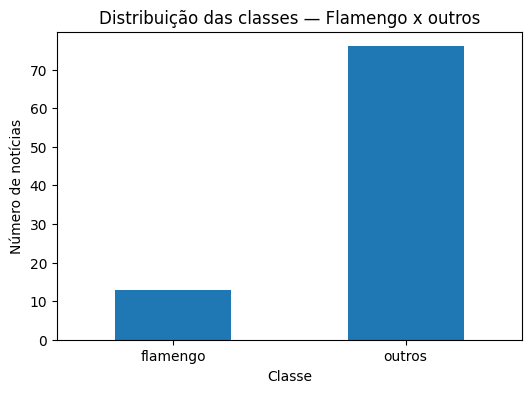

In [5]:
df["alvo_binario"] = df["secao"].map(lambda s: "flamengo" if s == "Flamengo" else "outros")

contagem = df["alvo_binario"].value_counts()
print(contagem)
print("\nProporção:")
print(df["alvo_binario"].value_counts(normalize=True).round(3))

contagem.sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Distribuição das classes — Flamengo x outros")
plt.xlabel("Classe")
plt.ylabel("Número de notícias")
plt.xticks(rotation=0)
plt.show()

### Separação entre treino e teste

80% para treino e 20% para teste, com `stratify=y` para preservar a proporção das classes.

In [6]:
X = df["entrada"]
y = df["alvo_binario"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Treino:", len(X_train), "| Teste:", len(X_test))
print("Flamengo no teste:", (y_test == "flamengo").sum())

Treino: 71 | Teste: 18
Flamengo no teste: 3


### TF-IDF + Regressão Logística

Mesmo pipeline da aula. Com uma base pequena, ajustamos os limites do vetorizador: `min_df=1` (em vez de 2) para não descartar termos raros, que aqui são muitos.

In [7]:
def criar_pipeline(classificador=None, vetorizador=None):
    return Pipeline([
        ("tfidf", vetorizador or TfidfVectorizer(
            lowercase=True, min_df=1, max_df=0.95, ngram_range=(1, 2), max_features=20_000
        )),
        ("classificador", classificador or LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])


modelo_binario = criar_pipeline()
modelo_binario.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=20000,
                                 ngram_range=(1, 2))),
                ('classificador',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Avaliação

Acurácia: 0.833

              precision    recall  f1-score   support

    flamengo      0.000     0.000     0.000         3
      outros      0.833     1.000     0.909        15

    accuracy                          0.833        18
   macro avg      0.417     0.500     0.455        18
weighted avg      0.694     0.833     0.758        18



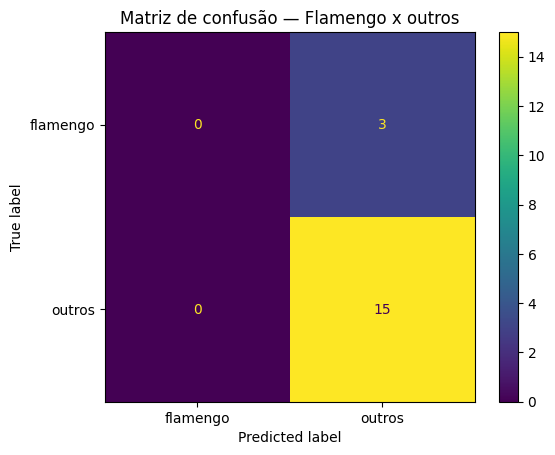

In [8]:
y_pred = modelo_binario.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusão — Flamengo x outros")
plt.show()

Com poucos exemplos no teste, uma única divisão é frágil, então repetimos a avaliação com **validação cruzada estratificada de 5 partições** e olhamos acurácia e F1 macro.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def validar(modelo, X, y, scoring=("accuracy", "f1_macro")):
    res = cross_validate(modelo, X, y, cv=cv, scoring=scoring)
    return {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in scoring}

cv_bin = validar(criar_pipeline(), X, y)

for metrica, (media, desvio) in cv_bin.items():
    print(f"{metrica}: {media:.3f} (±{desvio:.3f})")

accuracy: 0.854 (±0.026)
f1_macro: 0.461 (±0.007)


Como o modelo prevê só a classe majoritária, testamos , que dá mais peso aos erros na classe rara (como sugerido no exercício da aula).

In [10]:
modelo_bin_bal = criar_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
modelo_bin_bal.fit(X_train, y_train)
print("Teste (class_weight='balanced'):")
print(classification_report(y_test, modelo_bin_bal.predict(X_test), digits=3, zero_division=0))

cv_bin_bal = validar(modelo_bin_bal, X, y)
for metrica, (media, desvio) in cv_bin_bal.items():
    print(f"validação cruzada - {metrica}: {media:.3f} (±{desvio:.3f})")

Teste (class_weight='balanced'):
              precision    recall  f1-score   support

    flamengo      1.000     0.667     0.800         3
      outros      0.938     1.000     0.968        15

    accuracy                          0.944        18
   macro avg      0.969     0.833     0.884        18
weighted avg      0.948     0.944     0.940        18



validação cruzada - accuracy: 0.944 (±0.001)
validação cruzada - f1_macro: 0.871 (±0.026)


## O que o modelo aprendeu?

Examinamos os coeficientes da Regressão Logística. No caso binário, coeficientes positivos favorecem `classes_[1]` e negativos favorecem `classes_[0]`.

In [11]:
vetorizador = modelo_binario.named_steps["tfidf"]
classificador = modelo_binario.named_steps["classificador"]

coef_df = pd.DataFrame({
    "termo": vetorizador.get_feature_names_out(),
    "coeficiente": classificador.coef_[0],
}).sort_values("coeficiente")

print("Classes do modelo:", list(classificador.classes_))
print("\nTermos que favorecem", classificador.classes_[0])
display(coef_df.head(15))
print("Termos que favorecem", classificador.classes_[1])
display(coef_df.tail(15).sort_values("coeficiente", ascending=False))

baixar_tabela(pd.concat([coef_df.head(15), coef_df.tail(15)]), "01_coeficientes_binario.csv")

Classes do modelo: ['flamengo', 'outros']

Termos que favorecem flamengo


,termo,coeficiente
7840,flamengo,-0.775395
2134,arrascaeta,-0.759341
7039,do flamengo,-0.403931
16259,rubro,-0.307449
16261,rubro negro,-0.293136
11226,negro,-0.293136
14768,punho,-0.283400
6223,de arrascaeta,-0.268126
8163,fratura,-0.237134
12459,paquetá,-0.231702


Termos que favorecem outros


,termo,coeficiente
5682,cruzeiro,0.155897
5473,corinthians,0.155660
1486,anos,0.123662
19307,vasco,0.110126
5439,copa,0.093884
8310,fábio,0.091110
17450,sub,0.079338
8602,gols,0.078454
11131,nas,0.078213
9440,jorge,0.076765


Tabela salva em: tabelas_exportadas\01_coeficientes_binario.csv


### Testando frases novas

Como na aula, incluímos frases de teste. Algumas mencionam o clube de forma explícita e outras só tratam de futebol em geral.

In [12]:
novos_textos = [
    "O Flamengo venceu o jogo no Maracanã e Gabigol marcou o gol da vitória.",
    "O Corinthians contratou um novo zagueiro para a temporada.",
    "O técnico foi punido pela Conmebol após a expulsão.",
    "A CBF divulgou a tabela do Campeonato Brasileiro.",
    "Rubro-negro encara o decisivo jogo da Libertadores.",
]

previsoes = modelo_binario.predict(novos_textos)
probabilidades = modelo_binario.predict_proba(novos_textos)

resultado_novos = pd.DataFrame({
    "texto": novos_textos,
    "classe_prevista": previsoes,
    **{f"prob_{c}": probabilidades[:, i] for i, c in enumerate(classificador.classes_)},
}).round(3)
baixar_tabela(resultado_novos, "02_frases_novas_binario.csv")
resultado_novos

Tabela salva em: tabelas_exportadas\02_frases_novas_binario.csv


,texto,classe_prevista,prob_flamengo,prob_outros
0,O Flamengo venceu o jogo no Maracanã e Gabigol...,outros,0.135,0.865
1,O Corinthians contratou um novo zagueiro para ...,outros,0.115,0.885
2,O técnico foi punido pela Conmebol após a expu...,outros,0.120,0.880
3,A CBF divulgou a tabela do Campeonato Brasileiro.,outros,0.128,0.872
4,Rubro-negro encara o decisivo jogo da Libertad...,outros,0.164,0.836


## Problema 2 — classificação multiclasse: qual a seção?

Agora o alvo é a `secao` completa. Seções com menos de 5 notícias (como Botafogo) não permitem treino e avaliação minimamente razoáveis e ficam fora desta etapa.

Seções mantidas (11): ['Futebol Nacional', 'Flamengo', 'Vasco', 'Corinthians', 'Cruzeiro', 'Santos', 'São Paulo', 'Fluminense', 'Atlético Mineiro', 'Palmeiras', 'Fora de Campo']
Seções removidas: ['Botafogo']
Notícias usadas: 87


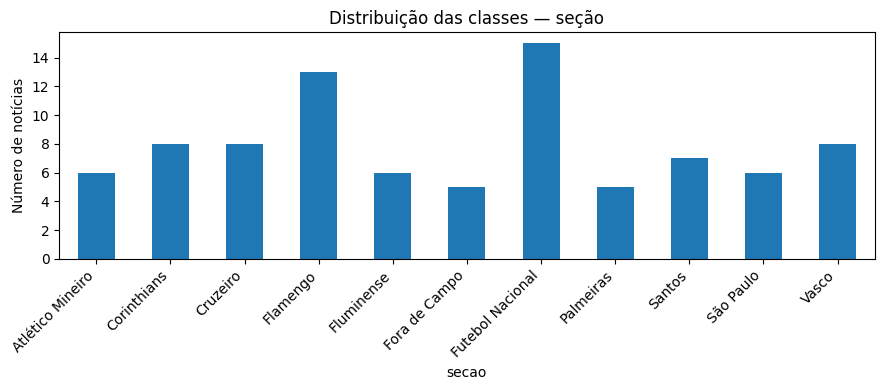

In [13]:
MIN_POR_CLASSE = 5
contagem_secoes = df["secao"].value_counts()
secoes_validas = contagem_secoes[contagem_secoes >= MIN_POR_CLASSE].index

df_multi = df[df["secao"].isin(secoes_validas)].reset_index(drop=True)
print(f"Seções mantidas ({len(secoes_validas)}):", list(secoes_validas))
print("Seções removidas:", list(contagem_secoes[contagem_secoes < MIN_POR_CLASSE].index))
print("Notícias usadas:", len(df_multi))

df_multi["secao"].value_counts().sort_index().plot(kind="bar", figsize=(9, 4))
plt.title("Distribuição das classes — seção")
plt.ylabel("Número de notícias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
X_multi = df_multi["entrada"]
y_multi = df_multi["secao"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=RANDOM_STATE, stratify=y_multi
)

modelo_multi = criar_pipeline()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_m = modelo_multi.predict(X_test_m)

print(f"Treino: {len(X_train_m)} | Teste: {len(X_test_m)}")
print(f"Acurácia: {accuracy_score(y_test_m, y_pred_m):.3f}\n")
print(classification_report(y_test_m, y_pred_m, digits=3, zero_division=0))

Treino: 65 | Teste: 22
Acurácia: 0.409

                  precision    recall  f1-score   support

Atlético Mineiro      0.000     0.000     0.000         2
     Corinthians      0.000     0.000     0.000         2
        Cruzeiro      1.000     0.500     0.667         2
        Flamengo      0.600     1.000     0.750         3
      Fluminense      0.000     0.000     0.000         1
   Fora de Campo      0.000     0.000     0.000         1
Futebol Nacional      0.267     1.000     0.421         4
       Palmeiras      0.000     0.000     0.000         1
          Santos      1.000     0.500     0.667         2
       São Paulo      0.000     0.000     0.000         2
           Vasco      0.000     0.000     0.000         2

        accuracy                          0.409        22
       macro avg      0.261     0.273     0.228        22
    weighted avg      0.312     0.409     0.300        22



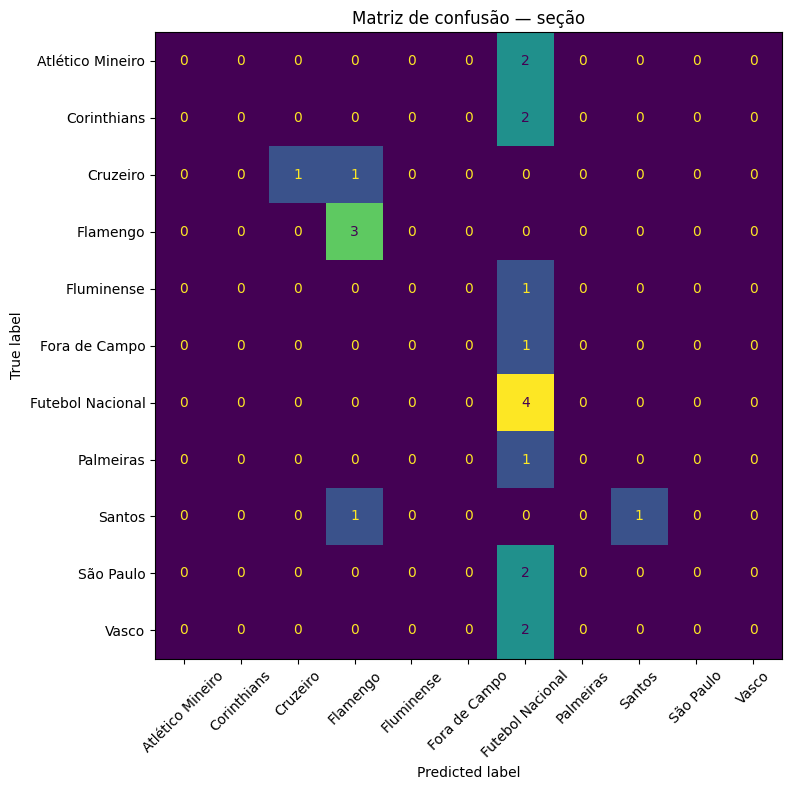

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_m, y_pred_m, ax=ax, xticks_rotation=45, colorbar=False
)
plt.title("Matriz de confusão — seção")
plt.tight_layout()
plt.show()

In [16]:
# Validação cruzada (mais confiável que uma divisão única com ~22 textos no teste)
cv_multi = validar(criar_pipeline(), X_multi, y_multi)
for metrica, (media, desvio) in cv_multi.items():
    print(f"{metrica}: {media:.3f} (±{desvio:.3f})")

accuracy: 0.414 (±0.065)
f1_macro: 0.239 (±0.058)


### Examinando os erros

Quais notícias o modelo errou e para qual seção ele as enviou?

In [17]:
erros = pd.DataFrame({
    "titulo": df_multi.loc[X_test_m.index, "titulo"],
    "real": y_test_m,
    "previsto": y_pred_m,
})
erros = erros[erros["real"] != erros["previsto"]]
baixar_tabela(erros, "03_erros_multiclasse.csv")
print(f"{len(erros)} erros em {len(y_test_m)} notícias de teste")
erros

Tabela salva em: tabelas_exportadas\03_erros_multiclasse.csv
13 erros em 22 notícias de teste


,titulo,real,previsto
70,Treino aberto do Atlético: veja o que chamou a...,Atlético Mineiro,Futebol Nacional
6,Fred revela interesse do Palmeiras antes de fe...,Palmeiras,Futebol Nacional
8,São Paulo encerra treino e tem novidades para ...,São Paulo,Futebol Nacional
73,Corinthians encerra parceria e perde mais um p...,Corinthians,Futebol Nacional
83,São Paulo acumula desfalques para pegar o Sant...,São Paulo,Futebol Nacional
12,Vasco vai à Justiça para jogar contra o Boca J...,Vasco,Futebol Nacional
79,Santos tem só dois atletas no DM; veja situaçã...,Santos,Flamengo
86,Fluminense tem dois retornos para a volta da D...,Fluminense,Futebol Nacional
4,"Torcedor do Palmeiras, Lito Sousa morre aos 59...",Fora de Campo,Futebol Nacional
26,Vasco x Boca: Pedrinho reforça preferência por...,Vasco,Futebol Nacional


## Experimentos: alterando um elemento do pipeline

Como sugerido ao fim da aula, mudamos um componente por vez e comparamos por validação cruzada, olhando acurácia e F1 macro (média do F1 por classe, que não deixa as classes grandes esconderem as pequenas).

Incluímos também um experimento próprio. As notícias costumam citar o nome do clube, então o modelo pode estar "colando" nesse nome. Em **sem nome do clube**, removemos do texto as palavras que formam os nomes das seções.

In [18]:
import re

# Palavras que compõem os nomes das seções (ex.: "atlético", "mineiro", "flamengo")
palavras_secao = set()
for secao in df["secao"].unique():
    palavras_secao |= {p.lower() for p in re.findall(r"\w+", secao) if len(p) > 3}
# "São Paulo" -> "paulo", "futebol", "nacional"... e apelidos mais comuns
palavras_secao |= {"fla", "rubro-negro", "timão", "verdão", "peixe", "tricolor", "cruzeiro", "galo", "raposa"}

def sem_clube(texto):
    return " ".join(p for p in texto.split() if re.sub(r"\W", "", p.lower()) not in palavras_secao)

X_multi_sem_clube = X_multi.apply(sem_clube)

config = {
    "base: TF-IDF 1-2gramas + LogReg": (criar_pipeline(), X_multi),
    "só unigramas": (criar_pipeline(vetorizador=TfidfVectorizer(min_df=1, max_df=0.95, ngram_range=(1, 1))), X_multi),
    "CountVectorizer (BoW)": (criar_pipeline(vetorizador=CountVectorizer(min_df=1, max_df=0.95, ngram_range=(1, 2))), X_multi),
    "LinearSVC": (criar_pipeline(classificador=LinearSVC(random_state=RANDOM_STATE)), X_multi),
    "LogReg class_weight=balanced": (criar_pipeline(classificador=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)), X_multi),
    "sem nome do clube": (criar_pipeline(), X_multi_sem_clube),
}

linhas = []
for nome, (modelo, entrada) in config.items():
    r = validar(modelo, entrada, y_multi)
    linhas.append({
        "experimento": nome,
        "acuracia": round(r["accuracy"][0], 3),
        "acuracia_desvio": round(r["accuracy"][1], 3),
        "f1_macro": round(r["f1_macro"][0], 3),
        "f1_macro_desvio": round(r["f1_macro"][1], 3),
    })

df_experimentos = pd.DataFrame(linhas)
baixar_tabela(df_experimentos, "04_experimentos_multiclasse.csv")
df_experimentos

Tabela salva em: tabelas_exportadas\04_experimentos_multiclasse.csv


,experimento,acuracia,acuracia_desvio,f1_macro,f1_macro_desvio
0,base: TF-IDF 1-2gramas + LogReg,0.414,0.065,0.239,0.058
1,só unigramas,0.437,0.032,0.272,0.027
2,CountVectorizer (BoW),0.692,0.112,0.584,0.081
3,LinearSVC,0.701,0.087,0.624,0.118
4,LogReg class_weight=balanced,0.701,0.042,0.633,0.072
5,sem nome do clube,0.323,0.063,0.160,0.045


In [19]:
# Quais termos mais favorecem cada seção no modelo base?
vet = modelo_multi.named_steps["tfidf"]
clf = modelo_multi.named_steps["classificador"]
termos = vet.get_feature_names_out()

linhas = []
for i, classe in enumerate(clf.classes_):
    top = clf.coef_[i].argsort()[::-1][:8]
    linhas.append({"secao": classe, "termos_mais_associados": ", ".join(termos[top])})

df_termos = pd.DataFrame(linhas)
baixar_tabela(df_termos, "05_termos_por_secao.csv")
df_termos

Tabela salva em: tabelas_exportadas\05_termos_por_secao.csv


,secao,termos_mais_associados
0,Atlético Mineiro,"galo, atlético, delfim, arena mrv, mrv, reinie..."
1,Corinthians,"corinthians, yuri, yuri alberto, alberto, chan..."
2,Cruzeiro,"cruzeiro, artur, artur jorge, jorge, temos, do..."
3,Flamengo,"arrascaeta, flamengo, fratura, punho, do flame..."
4,Fluminense,"fluminense, fábio, tricolor, maracanã, no mara..."
5,Fora de Campo,"giay, evellin, tradução, combate, rocinha, car..."
6,Futebol Nacional,"00, cabuloso, alef, anos, reinaldo, alef manga..."
7,Palmeiras,"abel ferreira, abel, ferreira, flaco, argentin..."
8,Santos,"santos, peixe, naty, do santos, rosa, ct rei, ..."
9,São Paulo,"são paulo, paulo, são, morumbis, mp, ticketmas..."


## Conclusão

Aplicamos o pipeline **texto → TF-IDF → Regressão Logística** da aula de classificação a duas tarefas sobre as 89 notícias do Lance!: Flamengo × outros (binária) e seção (multiclasse, 11 classes).

### Resultados

- **Binário**: a acurácia é alta (0,83 no teste, 0,85 na validação cruzada), mas o **F1 da classe Flamengo é 0**. O modelo prevê "outros" para tudo, e como 85% das notícias são "outros", isso já rende 85% de acurácia. É o exemplo da aula sobre por que acurácia sozinha engana com classes desbalanceadas. As frases novas confirmam: nenhuma, nem a que cita Flamengo e Gabigol explicitamente, foi classificada como Flamengo.
- **Correção com `class_weight="balanced"`**: no binário, o F1 do Flamengo vai de 0 para **0,80** no teste (precision 1,00, recall 0,67) e a validação cruzada dá acurácia **0,94** e F1 macro **0,87**, contra 0,46 do modelo sem balanceamento.
- **O que o modelo aprendeu** tem sentido: os maiores coeficientes para Flamengo são `flamengo`, `arrascaeta`, `rubro negro`, `fratura`, `punho`. Os dois últimos são de uma notícia específica da coleta (lesão de Arrascaeta), o que mostra quanto o modelo memoriza assuntos do dia em vez de aprender "o que é uma notícia do Flamengo".
- **Multiclasse**: acurácia de 0,41 e F1 macro de 0,24 na validação cruzada. Os erros vão quase todos para `Futebol Nacional`, a classe maior, e para `Flamengo`.
- **Experimentos** (validação cruzada, 5 partições): trocar TF-IDF por `CountVectorizer` subiu a acurácia para 0,69; `LinearSVC` e `class_weight="balanced"` chegaram a cerca de 0,70 (F1 macro 0,62 a 0,63). Com tão poucos textos, o TF-IDF normalizado deixa a regressão logística padrão fortemente regularizada, e isso a faz favorecer a classe majoritária. O `balanced` e o SVC corrigem isso.
- **Sem o nome do clube**: removendo as palavras que formam o nome das seções, a acurácia cai para 0,32 e o F1 macro para 0,16. Ou seja, boa parte do desempenho vem de o nome do clube aparecer no texto. Isso não é um defeito do método, mas é preciso saber disso ao interpretar o resultado.

### Limitações

Com 87 a 89 textos e classes de 5 a 15 exemplos, as métricas têm incerteza grande (desvios de 0,04 a 0,12 entre partições) e as diferenças pequenas entre experimentos não são conclusivas. As diferenças grandes (BoW e modelos balanceados contra o modelo base) são consistentes. A coleta de uma única data também faz o modelo associar clubes a assuntos do dia. Uma base acumulada por semanas (`python pipeline.py --acumular`) daria resultados mais confiáveis.
